# Random Forest on the 730-day feature set

The 730-day Logistic Regression is the current reference (test PR-AUC 0.173, ROC-AUC 0.720). This notebook tests whether Random Forest, using exactly the same 15 features and the same strict split, can extract more from the same information. This is a model comparison, not a new feature experiment, the feature set is fixed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
                              recall_score, f1_score, accuracy_score, confusion_matrix,
                              precision_recall_curve, roc_curve)

pred = pd.read_csv("../outputs/prediction_events_current_v1.csv",
                    parse_dates=["inspectionDate", "prev_inspectionDate"], low_memory=False)
long = pd.read_csv("../outputs/inspection_level_longitudinal.csv",
                    parse_dates=["inspectionDate"], low_memory=False)
long = long.sort_values(["estId", "inspectionDate"]).reset_index(drop=True)
print("prediction rows:", len(pred))

prediction rows: 69766


## Rebuild the 730-day features

Same calculation as the previous notebook, `prediction_events_current_v1.csv` only has the 365-day features, so the 730-day ones are recomputed from the longitudinal table and merged in.

In [2]:
long["is_non_pass"] = long["inspectionStatus"].isin(["Conditional Pass", "Closed"]).astype(int)

def rolling_730(g):
    g = g.reset_index()
    dates = g["inspectionDate"].values.astype("datetime64[D]")
    total_infr = g["n_infractions"].to_numpy()
    crucial = g["n_crucial"].to_numpy()
    non_pass = g["is_non_pass"].to_numpy()

    cs_infr = np.concatenate([[0], np.cumsum(total_infr)])
    cs_crucial = np.concatenate([[0], np.cumsum(crucial)])
    cs_nonpass = np.concatenate([[0], np.cumsum(non_pass)])

    lower_edge = dates - np.timedelta64(730, "D")
    low_idx = np.searchsorted(dates, lower_edge, side="left")

    idx_arr = np.arange(len(g))
    return pd.DataFrame({
        "orig_index": g["index"],
        "prior_730d_n_inspections": idx_arr - low_idx,
        "prior_730d_n_non_pass": cs_nonpass[idx_arr] - cs_nonpass[low_idx],
        "prior_730d_total_infractions": cs_infr[idx_arr] - cs_infr[low_idx],
        "prior_730d_crucial_infractions": cs_crucial[idx_arr] - cs_crucial[low_idx],
    })

rolled = long.groupby("estId", group_keys=False).apply(rolling_730).set_index("orig_index")
long_feat = long.join(rolled)

hist_730 = long_feat[["estId", "inspectionDate", "prior_730d_n_inspections", "prior_730d_n_non_pass",
                       "prior_730d_total_infractions", "prior_730d_crucial_infractions"]]

df = pred.merge(hist_730, on=["estId", "inspectionDate"], how="left")
assert len(df) == len(pred)
assert df["prior_730d_n_inspections"].isna().sum() == 0
print("merged rows:", len(df))

merged rows: 69766


## 15 features, fixed for both models

In [3]:
BASE = ["days_since_previous_inspection", "prev_non_pass", "prev_total_infractions",
        "prev_minor", "prev_significant", "prev_crucial", "n_inspections_seen_so_far"]
HIST365 = ["prior_365d_n_inspections", "prior_365d_n_non_pass",
           "prior_365d_total_infractions", "prior_365d_crucial_infractions"]
HIST730 = ["prior_730d_n_inspections", "prior_730d_n_non_pass",
           "prior_730d_total_infractions", "prior_730d_crucial_infractions"]

FEATURES = BASE + HIST365 + HIST730
assert len(FEATURES) == 15

identifier_cols = {"estId", "oldEstId", "_id", "unique_id"}
outcome_cols = {"OutcomeDate", "OutcomeDesc", "amountFined", "inspectionStatus"}
assert identifier_cols.isdisjoint(FEATURES)
assert outcome_cols.isdisjoint(FEATURES)
FEATURES

['days_since_previous_inspection',
 'prev_non_pass',
 'prev_total_infractions',
 'prev_minor',
 'prev_significant',
 'prev_crucial',
 'n_inspections_seen_so_far',
 'prior_365d_n_inspections',
 'prior_365d_n_non_pass',
 'prior_365d_total_infractions',
 'prior_365d_crucial_infractions',
 'prior_730d_n_inspections',
 'prior_730d_n_non_pass',
 'prior_730d_total_infractions',
 'prior_730d_crucial_infractions']

## Strict temporal split, same as Prompts 8 and 9

In [4]:
df = df.sort_values("inspectionDate").reset_index(drop=True)

unique_dates = np.sort(df["inspectionDate"].unique())
n_dates = len(unique_dates)
train_cut = unique_dates[int(n_dates * 0.70)]
val_cut = unique_dates[int(n_dates * 0.85)]

train = df[df["inspectionDate"] < train_cut].copy()
val = df[(df["inspectionDate"] >= train_cut) & (df["inspectionDate"] < val_cut)].copy()
test = df[df["inspectionDate"] >= val_cut].copy()

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name}: rows={len(part)} {part['inspectionDate'].min().date()} to {part['inspectionDate'].max().date()}")

assert len(train) == 45334 and len(val) == 11740 and len(test) == 12692
assert train["inspectionDate"].max() < val["inspectionDate"].min()
assert val["inspectionDate"].max() < test["inspectionDate"].min()
print("split matches Prompts 8 and 9 exactly")

train: rows=45334 2023-11-10 to 2025-11-05
val: rows=11740 2025-11-06 to 2026-04-09
test: rows=12692 2026-04-10 to 2026-09-08
split matches Prompts 8 and 9 exactly


## Leakage checks

In [5]:
assert not df.duplicated(subset=["estId", "inspectionDate"]).any()
assert (df["inspectionDate"] > df["prev_inspectionDate"]).all()
assert df["inspectionDate"].min() >= pd.Timestamp("2023-11-10")
assert df["inspectionDate"].max() <= pd.Timestamp("2026-09-08")
print("leakage checks passed")

X_train, y_train = train[FEATURES], train["target"]
X_val, y_val = val[FEATURES], val["target"]
X_test, y_test = test[FEATURES], test["target"]

leakage checks passed


## Shared evaluation function

Same threshold procedure and metrics as before, used identically for both models so the comparison is apples to apples.

In [6]:
def evaluate(pipe, label):
    val_proba = pipe.predict_proba(X_val)[:, 1]
    val_pr_auc = average_precision_score(y_val, val_proba)
    val_roc_auc = roc_auc_score(y_val, val_proba)

    thresh_rows = []
    for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
        p = (val_proba >= t).astype(int)
        thresh_rows.append({"threshold": t, "f1": f1_score(y_val, p, zero_division=0)})
    thresh_df = pd.DataFrame(thresh_rows)
    best_t = thresh_df.loc[thresh_df["f1"].idxmax(), "threshold"]

    test_proba = pipe.predict_proba(X_test)[:, 1]
    test_pred = (test_proba >= best_t).astype(int)

    metrics = {
        "label": label,
        "val_pr_auc": val_pr_auc, "val_roc_auc": val_roc_auc, "threshold": best_t,
        "test_pr_auc": average_precision_score(y_test, test_proba),
        "test_roc_auc": roc_auc_score(y_test, test_proba),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0),
        "test_f1": f1_score(y_test, test_pred, zero_division=0),
        "test_accuracy": accuracy_score(y_test, test_pred),
    }
    cm = confusion_matrix(y_test, test_pred)
    return metrics, cm, test_proba

## Logistic Regression reference

Same pipeline and model as Prompt 9, reproduced here on the same 15 features so both models are trained and evaluated in this notebook under identical conditions.

In [7]:
pipe_lr = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
pipe_lr.fit(X_train, y_train)
metrics_lr, cm_lr, proba_lr = evaluate(pipe_lr, "logistic_regression")
print(metrics_lr)
print(cm_lr)

{'label': 'logistic_regression', 'val_pr_auc': 0.16315724236893614, 'val_roc_auc': 0.7297854612163733, 'threshold': np.float64(0.6), 'test_pr_auc': 0.17316561173976583, 'test_roc_auc': 0.7202057107789819, 'test_precision': 0.18168316831683168, 'test_recall': 0.38469601677148846, 'test_f1': 0.24680564895763282, 'test_accuracy': 0.8235108729908603}
[[10085  1653]
 [  587   367]]


In [8]:
saved_lr = pd.read_csv("../outputs/logistic_730d_history_results.csv").iloc[0]
print("saved Prompt 9 test PR-AUC:", saved_lr["test_pr_auc"], " this notebook's:", metrics_lr["test_pr_auc"])
assert abs(saved_lr["test_pr_auc"] - metrics_lr["test_pr_auc"]) < 1e-9
assert abs(saved_lr["test_roc_auc"] - metrics_lr["test_roc_auc"]) < 1e-9
print("logistic regression reference reproduces Prompt 9 exactly")

saved Prompt 9 test PR-AUC: 0.1731656117397658  this notebook's: 0.17316561173976583
logistic regression reference reproduces Prompt 9 exactly


## Random Forest

No standardization needed for a tree model, so the pipeline is just imputation plus the classifier. No tuning, this is a fixed baseline configuration.

In [9]:
pipe_rf = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)),
])
pipe_rf.fit(X_train, y_train)
metrics_rf, cm_rf, proba_rf = evaluate(pipe_rf, "random_forest")
print(metrics_rf)
print(cm_rf)

{'label': 'random_forest', 'val_pr_auc': 0.10490853527588556, 'val_roc_auc': 0.6638759796046186, 'threshold': np.float64(0.3), 'test_pr_auc': 0.11544644296676074, 'test_roc_auc': 0.6523021593398566, 'test_precision': 0.1355081555834379, 'test_recall': 0.22641509433962265, 'test_f1': 0.1695447409733124, 'test_accuracy': 0.8332808068074378}
[[10360  1378]
 [  738   216]]


## Comparison

In [10]:
compare = pd.DataFrame([metrics_lr, metrics_rf])
compare = compare[["label", "val_pr_auc", "val_roc_auc", "threshold", "test_pr_auc",
                    "test_roc_auc", "test_precision", "test_recall", "test_f1", "test_accuracy"]]
compare

,label,val_pr_auc,val_roc_auc,threshold,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1,test_accuracy
0,logistic_regression,0.163157,0.729785,0.6,0.173166,0.720206,0.181683,0.384696,0.246806,0.823511
1,random_forest,0.104909,0.663876,0.3,0.115446,0.652302,0.135508,0.226415,0.169545,0.833281


Random Forest scores lower than Logistic Regression on every ranking metric here (test PR-AUC 0.173 vs 0.115, ROC-AUC 0.720 vs 0.652). The more flexible model did not translate into better out-of-time performance under this fixed configuration, on this feature set. This isn't evidence that Random Forest can never help, an untuned 300-tree forest on 15 mostly-count features and a rare positive class is a fairly narrow setup, but as run here it underperforms the simpler linear model.

## PR and ROC curves

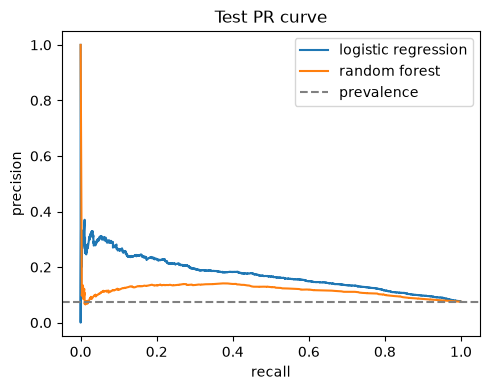

In [11]:
prec_lr, rec_lr, _ = precision_recall_curve(test["target"], proba_lr)
prec_rf, rec_rf, _ = precision_recall_curve(test["target"], proba_rf)

plt.figure(figsize=(5, 4))
plt.plot(rec_lr, prec_lr, label="logistic regression")
plt.plot(rec_rf, prec_rf, label="random forest")
plt.axhline(test["target"].mean(), linestyle="--", color="gray", label="prevalence")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Test PR curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/random_forest_730d_pr_curve.png", dpi=100)
plt.show()

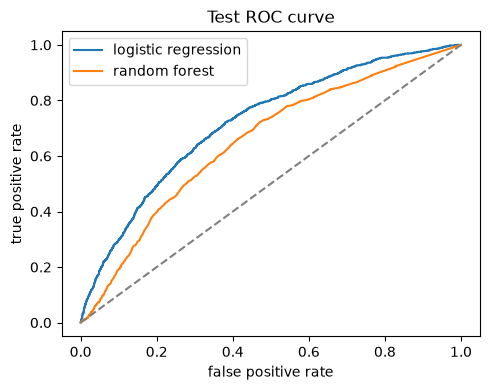

In [12]:
fpr_lr, tpr_lr, _ = roc_curve(test["target"], proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(test["target"], proba_rf)

plt.figure(figsize=(5, 4))
plt.plot(fpr_lr, tpr_lr, label="logistic regression")
plt.plot(fpr_rf, tpr_rf, label="random forest")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Test ROC curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/random_forest_730d_roc_curve.png", dpi=100)
plt.show()

## Random Forest feature importance (impurity-based)

This is the built-in scikit-learn impurity-based importance, not SHAP, and not a causal effect. It just shows which features the trees split on most.

In [13]:
importances = pipe_rf.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature": FEATURES, "importance": importances}).sort_values("importance", ascending=False).reset_index(drop=True)
imp_df

,feature,importance
0,days_since_previous_inspection,0.358341
1,n_inspections_seen_so_far,0.189196
2,prior_730d_total_infractions,0.118510
3,prior_365d_total_infractions,0.073240
4,prior_730d_n_inspections,0.065315
5,prior_365d_n_inspections,0.036907
6,prev_total_infractions,0.033664
7,prev_minor,0.032255
8,prior_730d_crucial_infractions,0.023111
9,prev_significant,0.021805


`days_since_previous_inspection` and `n_inspections_seen_so_far` dominate the importance ranking here, more than the infraction-count features. This is a descriptive summary of how the forest is splitting, not proof that timing matters more than infraction history in any causal sense.

## Save results

In [14]:
results = pd.DataFrame([
    {"model": "random_forest", "feature_set": "previous inspection + 365-day + 730-day history (15 features)",
     "val_pr_auc": metrics_rf["val_pr_auc"], "val_roc_auc": metrics_rf["val_roc_auc"],
     "threshold": metrics_rf["threshold"],
     "test_pr_auc": metrics_rf["test_pr_auc"], "test_roc_auc": metrics_rf["test_roc_auc"],
     "test_precision": metrics_rf["test_precision"], "test_recall": metrics_rf["test_recall"],
     "test_f1": metrics_rf["test_f1"], "test_accuracy": metrics_rf["test_accuracy"],
     "train_rows": len(train), "val_rows": len(val), "test_rows": len(test),
     "train_start": train["inspectionDate"].min(), "train_end": train["inspectionDate"].max(),
     "val_start": val["inspectionDate"].min(), "val_end": val["inspectionDate"].max(),
     "test_start": test["inspectionDate"].min(), "test_end": test["inspectionDate"].max()},
])
results.to_csv("../outputs/random_forest_730d_results.csv", index=False)
imp_df.to_csv("../outputs/random_forest_730d_feature_importance.csv", index=False)
print("saved outputs/random_forest_730d_results.csv")
print("saved outputs/random_forest_730d_feature_importance.csv")

saved outputs/random_forest_730d_results.csv
saved outputs/random_forest_730d_feature_importance.csv


## Interpretation

With the feature set and split held fixed, Logistic Regression (test PR-AUC 0.173, ROC-AUC 0.720) outperformed the untuned Random Forest (test PR-AUC 0.115, ROC-AUC 0.652) on this data. The more flexible model did not translate into better out-of-time performance under this fixed configuration. This predicts the recorded DineSafe Non-Pass outcome, not an absolute measure of food safety, and the result says something about model fit on these particular engineered features, not that tree models are generally worse for this kind of problem. No hyperparameter tuning was done here, that's a natural next question rather than something to explore in this notebook.